© 2025 Mobile Perception Systems Lab at TU/e. All rights reserved. Licensed under the MIT License.

## Setup

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [23]:
cd /content/drive/MyDrive/AnomalySegmentation_Project/eomt

/content/drive/MyDrive/AnomalySegmentation_Project/eomt


In [5]:
!pip install -r requirements.txt

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.2/192.2 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 81.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 61.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11

In [12]:
import yaml
from lightning import seed_everything
import torch
from torch.nn import functional as F
from torch.amp.autocast_mode import autocast
import matplotlib.pyplot as plt
import numpy as np
import warnings
import importlib

seed_everything(0, verbose=False)

device = 0  # TODO: change to the GPU you want to use
img_idx = 100 # TODO: change to the index of the image you want to visualize
config_path_coco = "configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml"
config_path_cityscapes = "configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"
data_path = "../Cityscapes"  # TODO: change to the dataset directory

with open(config_path_coco, "r") as f:
    config_coco = yaml.safe_load(f)

with open(config_path_cityscapes, "r") as f:
    config_city = yaml.safe_load(f)

def create_mapping(images, ignore_index):
    unique_ids = np.unique(np.concatenate([np.unique(img) for img in images]))
    valid_ids = unique_ids[unique_ids != ignore_index]
    colors = np.array(
        [plt.cm.hsv(i / len(valid_ids))[:3] for i in range(len(valid_ids))]
    )
    mapping = {cid: colors[i] for i, cid in enumerate(valid_ids)}
    mapping[ignore_index] = np.array([0, 0, 0])
    return mapping


def apply_colormap(image, mapping):
    colored_image = np.zeros((*image.shape, 3))
    for cid in np.unique(image):
        colored_image[image == cid] = mapping.get(cid, [0, 0, 0])
    return colored_image

In [25]:
# Check if CUDA (NVIDIA GPU) is available
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("No GPU detected, using CPU.")


GPU detected: Tesla T4


## Load dataset

Ensure the dataset files are correctly prepared and placed in the folder specified by `data_path`.

In [21]:
#CITYSCAPES
data_module_name_city, class_name_city = config_city["data"]["class_path"].rsplit(".", 1)
data_module_city = getattr(importlib.import_module(data_module_name_city), class_name_city)
data_kwargs_city = config_city["data"].get("init_args", {})

data_city = data_module_city(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_kwargs_city
)
data_city.setup()


#COCO
data_module_name_coco, class_name_coco = config_coco["data"]["class_path"].rsplit(".", 1)
data_module_coco = getattr(importlib.import_module(data_module_name_coco), class_name_coco)
data_kwargs_coco = config_coco["data"].get("init_args", {})

data_coco_meta = data_module_coco(
    path="",
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_kwargs_coco
)

## Load model

In [26]:
warnings.filterwarnings(
    "ignore",
    message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*",
)

def build_and_load_model(config, data_meta, weights_path):
    # Load encoder
    encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
    encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
    encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
    encoder = encoder_cls(img_size=data_meta.img_size, **encoder_cfg.get("init_args", {}))

    # Load network
    network_cfg = config["model"]["init_args"]["network"]
    network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
    network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
    network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}

    network = network_cls(
        masked_attn_enabled=False,
        num_classes=data_meta.num_classes,
        encoder=encoder,
        **network_kwargs,
    )

    # Load Lightning module
    lit_module_name, lit_class_name = config["model"]["class_path"].rsplit(".", 1)
    lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
    model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}

    if "stuff_classes" in config["data"].get("init_args", {}):
        model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

    name = config.get("trainer", {}).get("logger", {}).get("init_args", {}).get("name", "")
    is_dinov3 = "dinov3" in name

    if is_dinov3:
        model_kwargs["ckpt_path"] = weights_path
        model_kwargs["delta_weights"] = True

    model = (
        lit_cls(
            img_size=data_meta.img_size,
            num_classes=data_meta.num_classes,
            network=network,
            **model_kwargs,
        )
        .eval()
        .to(device)
    )

    if not is_dinov3:
        try:
            ckpt = torch.load(weights_path, map_location=device)
            if isinstance(ckpt, dict) and "state_dict" in ckpt:
                state_dict = ckpt["state_dict"]
            else:
                state_dict = ckpt
            model.load_state_dict(state_dict, strict=False)
            print(f"Weights successfully loaded from {weights_path}!")
            
        except Exception as e:
            print(f"Error loading weights from {weights_path}: {e}")

    return model

#COCO
state_dict_path_coco = "weights/eomt_coco.bin"
print("Initializing COCO Panoptic model...")
model_panoptic = build_and_load_model(config_coco, data_coco_meta, state_dict_path_coco)

#CITYSCAPES
state_dict_path_city = "weights/eomt_cityscapes.bin"
print("Initializing Cityscapes Semantic model...")
model_semantic = build_and_load_model(config_city, data_city, state_dict_path_city)

Initializing COCO Panoptic model...
Weights successfully loaded from weights/eomt_coco.bin!
Initializing Cityscapes Semantic model...
Weights successfully loaded from weights/eomt_cityscapes.bin!


## Semantic inference (pixel-wise classification)

> This inference method also works when applied to a model trained for panoptic segmentation.

Semantic inference computes per-pixel class scores by combining mask and class predictions:

$$
\sum_i p_i(c) \cdot m_i[h, w]
$$

Here, $p_i(c)$ is the class probability for class $c$ (excluding "no object"), and $m_i[h, w]$ is the sigmoid-normalized mask value for query $i$ at pixel $(h, w)$. The final class is selected by taking the argmax over classes.  
  
*This inference method was originally introduced in MaskFormer.*

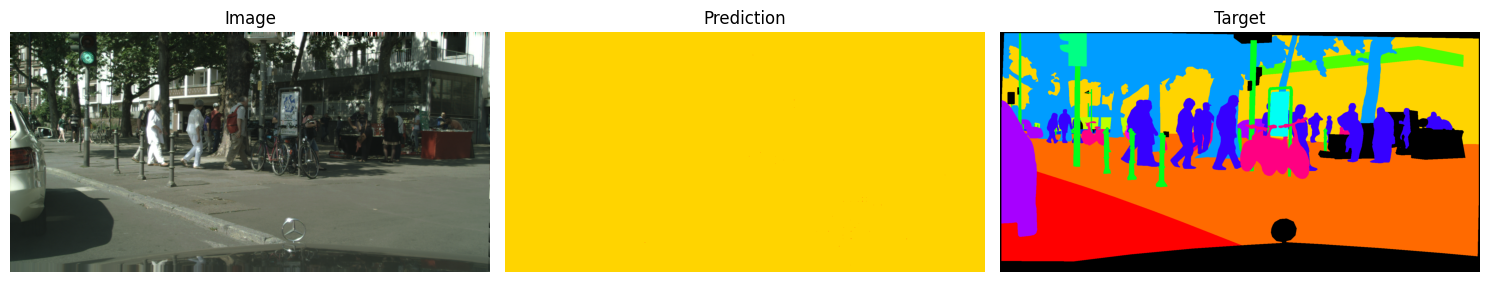

In [20]:
IGNORE_INDEX = 255

def infer_semantic(model_sem, data_val, img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]

        crops, origins = model_sem.window_imgs_semantic(imgs)

        mask_logits_per_layer, class_logits_per_layer = model_sem(crops)

        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], data_val.img_size, mode="bilinear"
        )

        crop_logits = model_sem.to_per_pixel_logits_semantic(
            mask_logits, class_logits_per_layer[-1]
        )
        logits = model_sem.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        preds = logits[0].argmax(0).cpu()

    pred_array = preds.numpy()
    target_array = model_sem.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[
        0
    ].numpy()
    return pred_array, target_array


def plot_semantic_results(img, pred_array, target_array):
    mapping = create_mapping([pred_array, target_array], IGNORE_INDEX)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Image")
    axes[1].imshow(apply_colormap(pred_array, mapping))
    axes[1].set_title("Prediction")
    axes[2].imshow(apply_colormap(target_array, mapping))
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

img, target = data_city.val_dataloader().dataset[img_idx]
pred_array, target_array = infer_semantic(model_semantic, data_city, img, target)
plot_semantic_results(img, pred_array, target_array)

## Panoptic inference (segmentation with instance IDs)

> This inference method also works when applied to a model trained for instance segmentation.

Panoptic inference assigns each pixel $[h, w]$ to the query $i$ that maximizes the product of class and mask confidence:

$$
p_i(c_i) \cdot m_i[h, w]
$$

where $c_i = \arg\max_c \, p_i(c)$ is the most likely class for query $i$. A pixel is assigned to a query only if both the class confidence and mask confidence are high. Pixels assigned to the same query form a segment labeled with $c_i$. "Stuff" segments with the same class are merged; "thing" segments are kept distinct using the query index. Low-confidence and heavily occluded predictions are filtered out.  
  
*This inference method was originally introduced in MaskFormer.*

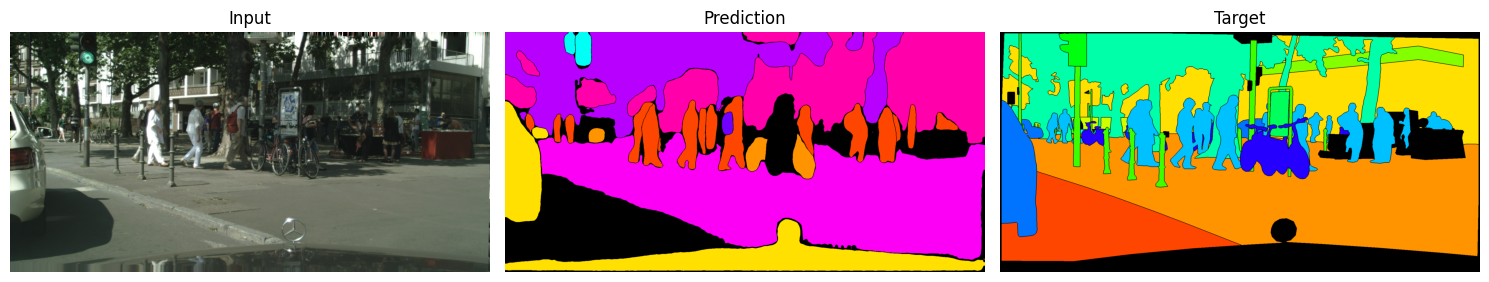

In [14]:
def infer_panoptic(model_pan, img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]

        transformed_imgs = model_pan.resize_and_pad_imgs_instance_panoptic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model_pan(transformed_imgs)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], model_pan.img_size, mode="bilinear"
        )
        mask_logits = model_pan.revert_resize_and_pad_logits_instance_panoptic(
            mask_logits, img_sizes
        )

        preds = model_pan.to_per_pixel_preds_panoptic(
            mask_logits,
            class_logits_per_layer[-1],
            model_pan.stuff_classes,
            model_pan.mask_thresh,
            model_pan.overlap_thresh,
        )[0].cpu()

    pred = preds.numpy()
    sem_pred, inst_pred = pred[..., 0], pred[..., 1]

    target_seg = model_pan.to_per_pixel_targets_panoptic([target])[0].cpu().numpy()
    sem_target, inst_target = target_seg[..., 0], target_seg[..., 1]

    return sem_pred, inst_pred, sem_target, inst_target


def draw_black_border(sem, inst, mapping):
    h, w = sem.shape
    out = np.zeros((h, w, 3))
    for s in np.unique(sem):
        out[sem == s] = mapping[s]

    combined = sem.astype(np.int64) * 100000 + inst.astype(np.int64)
    border = np.zeros((h, w), dtype=bool)
    border[1:, :] |= combined[1:, :] != combined[:-1, :]
    border[:-1, :] |= combined[1:, :] != combined[:-1, :]
    border[:, 1:] |= combined[:, 1:] != combined[:, :-1]
    border[:, :-1] |= combined[:, 1:] != combined[:, :-1]
    out[border] = 0
    return out


def plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target, num_classes):
    all_ids = np.union1d(np.unique(sem_pred), np.unique(sem_target))
    mapping = {
        s: (
            [0, 0, 0]
            if s == -1 or s == num_classes
            else plt.cm.hsv(i / len(all_ids))[:3]
        )
        for i, s in enumerate(all_ids)
    }

    vis_pred = draw_black_border(sem_pred, inst_pred, mapping)
    vis_target = draw_black_border(sem_target, inst_target, mapping)

    img_np = (
        img.cpu().numpy().transpose(1, 2, 0) if img.dim() == 3 else img.cpu().numpy()
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_np)
    axes[0].set_title("Input")
    axes[1].imshow(vis_pred)
    axes[1].set_title("Prediction")
    axes[2].imshow(vis_target)
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


img, target = data_city.val_dataloader().dataset[img_idx]
sem_pred, inst_pred, sem_target, inst_target = infer_panoptic(model_panoptic, img, target)
plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target, model_panoptic.num_classes)

## Cityscapes vs Coco on Cityscapes Dataset

In [24]:
from torchmetrics.classification import MulticlassJaccardIndex
from tqdm import tqdm

IGNORE_INDEX = 255

# 1. EVALUATION STRATEGY
# num_classes=20 (Indices 0-18: Cityscapes classes, Index 19: Sink class for errors and non-matching labels).
metric_city = MulticlassJaccardIndex(num_classes=20, ignore_index=IGNORE_INDEX, average="none").to(device)
metric_coco = MulticlassJaccardIndex(num_classes=20, ignore_index=IGNORE_INDEX, average="none").to(device)

# 2. CREATE AND POPULATE MAPPING TENSOR (Size 256 for crash prevention, initialized with 19)
mapping_tensor = torch.full((256,), 19, dtype=torch.long, device=device)

mapping_tensor[0] = 11   # person -> person
mapping_tensor[1] = 18   # bicycle -> bicycle
mapping_tensor[2] = 13   # car -> car
mapping_tensor[3] = 17   # motorcycle -> motorcycle

mapping_tensor[5] = 15   # bus -> bus
mapping_tensor[6] = 16   # train -> train
mapping_tensor[7] = 14   # truck -> truck

mapping_tensor[9] = 6    # traffic light -> traffic light

mapping_tensor[11] = 7   # stop sign -> traffic sign

mapping_tensor[86] = 2   # door-stuff -> building
mapping_tensor[87] = 9   # floor-wood -> terrain
mapping_tensor[88] = 8   # flower -> vegetation
mapping_tensor[91] = 2   # house -> building
mapping_tensor[96] = 2   # platform -> building
mapping_tensor[100] = 0  # road -> road
mapping_tensor[101] = 2  # roof -> building
mapping_tensor[102] = 9  # sand -> terrain


mapping_tensor[109] = 3  # wall-brick -> wall
mapping_tensor[110] = 3  # wall-stone -> wall
mapping_tensor[111] = 3  # wall-tile -> wall
mapping_tensor[112] = 3  # wall-wood -> wall
mapping_tensor[114] = 2  # window-blind -> building
mapping_tensor[115] = 2  # window-other -> building
mapping_tensor[116] = 8  # tree-merged -> vegetation
mapping_tensor[117] = 4  # fence-merged -> fence
mapping_tensor[119] = 10 # sky-other-merged -> sky
mapping_tensor[123] = 1 # pavement-merged -> sidewalk
mapping_tensor[129] = 2  # building-other -> building
mapping_tensor[131] = 3  # wall-other -> wall

mapping_tensor[116] = 8  # tree -> vegetation
mapping_tensor[125] = 8  # grass -> vegetation
mapping_tensor[88] = 8   # flower -> vegetation
mapping_tensor[90] = 9   # gravel -> terrain
mapping_tensor[102] = 9  # sand -> terrain
mapping_tensor[126] = 9  # dirt -> terrain

# 3. EVALUATION LOOP
val_dataloader = data_city.val_dataloader()

model_semantic.eval()
model_panoptic.eval()

print("Starting quantitative mIoU evaluation...")

for batch_idx, batch in enumerate(tqdm(val_dataloader, desc="Processing")):
    batched_imgs, batched_targets = batch
    img = batched_imgs[0]
    target = batched_targets[0]

    # --- Cityscapes Model (Native) ---
    preds_city_np, target_array_np = infer_semantic(model_semantic, data_city, img, target)

    preds_city_tensor = torch.tensor(preds_city_np, device=device)
    target_tensor = torch.tensor(target_array_np, device=device)
    metric_city.update(preds_city_tensor, target_tensor)

    # --- COCO Model (Mapped) ---
    preds_coco_np, _ = infer_semantic(model_panoptic, data_coco_meta, img, target)
    preds_coco_tensor = torch.tensor(preds_coco_np, device=device)

    # Instant vectorized mapping
    preds_mapped_tensor = mapping_tensor[preds_coco_tensor]
    metric_coco.update(preds_mapped_tensor, target_tensor)

# 4. RESULTS CALCULATION AND DISPLAY
iou_array_city = metric_city.compute()
iou_array_coco = metric_coco.compute()

# Definiamo il mapping completo basato su quello che hai inserito nel mapping_tensor
# Escludiamo 5 (pole) e 12 (rider) perché non sono mappati dal tuo codice COCO
class_info = [
    (0, "road"),
    (1, "sidewalk"),
    (2, "building"),
    (3, "wall"),
    (4, "fence"),
    (6, "traffic light"),
    (7, "traffic sign"),
    (8, "vegetation"),
    (9, "terrain"),
    (10, "sky"),
    (11, "person"),
    (13, "car"),
    (14, "truck"),
    (15, "bus"),
    (16, "train"),
    (17, "motorcycle"),
    (18, "bicycle")
]

all_mapped_ids = [info[0] for info in class_info]
names = [info[1] for info in class_info]

print("\n" + "="*75)
print(f"{'CLASS':<20} | {'Cityscapes IoU (%)':<22} | {'COCO Mapped IoU (%)':<20}")
print("-" * 75)

for cid, name in zip(all_mapped_ids, names):
    val_city = iou_array_city[cid].item() * 100
    val_coco = iou_array_coco[cid].item() * 100

    # Formattazione per gestire i NaN (se una classe non compare nel dataset)
    city_str = f"{val_city:>18.2f}" if not torch.isnan(iou_array_city[cid]) else f"{'N/A':>18}"
    coco_str = f"{val_coco:>18.2f}" if not torch.isnan(iou_array_coco[cid]) else f"{'N/A':>18}"

    print(f"{name:<20} | {city_str} | {coco_str}")

# Calcolo mIoU finale solo sulle classi effettivamente valutate
valid_city = iou_array_city[all_mapped_ids][~torch.isnan(iou_array_city[all_mapped_ids])]
valid_coco = iou_array_coco[all_mapped_ids][~torch.isnan(iou_array_coco[all_mapped_ids])]

miou_city = torch.mean(valid_city).item() * 100 if len(valid_city) > 0 else 0
miou_coco = torch.mean(valid_coco).item() * 100 if len(valid_coco) > 0 else 0

print("-" * 75)
print(f"{'TOTAL mIoU':<20} | {miou_city:>18.2f} | {miou_coco:>18.2f}")
print("=" * 75)

metric_city.reset()
metric_coco.reset()

Starting quantitative mIoU evaluation...


Processing: 100%|██████████| 500/500 [06:48<00:00,  1.22it/s]


CLASS                | Cityscapes IoU (%)     | COCO Mapped IoU (%) 
---------------------------------------------------------------------------
road                 |              98.40 |              94.01
sidewalk             |              87.36 |              64.74
building             |              94.15 |              87.04
wall                 |              66.07 |              45.77
fence                |              65.49 |              48.09
traffic light        |              75.00 |              60.37
traffic sign         |              82.13 |               4.41
vegetation           |              93.02 |              85.10
terrain              |              66.60 |               5.83
sky                  |              95.54 |              89.70
person               |              85.38 |              67.22
car                  |              95.54 |              84.22
truck                |              81.79 |              29.34
bus                  |             

In [14]:
!mkdir -p /content/Cityscapes_local
!cp /content/drive/MyDrive/AnomalySegmentation_Project/Cityscapes/*.zip /content/Cityscapes_local/

In [2]:
!wandb login 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

wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Finetune only Head

In [ ]:
!python main.py fit \
  -c configs/dinov2/cityscapes/semantic/eomt_finetune_base.yaml \
  --data.batch_size 4   \
  --model.init_args.img_size [640, 640] \
  --data.path /content/Cityscapes_local \
  --trainer.devices 1 \
  --trainer.logger.init_args.name "cityscapes_finetune_only_Head_batch4_prova" \
  --trainer.logger.init_args.version "finetune_only_Head_batch4_prova" \
  --model.network.init_args.unfreeze_last_n_blocks 0 \
  --model.load_ckpt_class_head False \
  --model.ckpt_path "./weights/eomt_coco.bin"

Finetune Unfreeze 1

In [ ]:
!python main.py fit \
  -c configs/dinov2/cityscapes/semantic/eomt_finetune_base.yaml \
  --data.batch_size 4 \
  --model.init_args.img_size [640, 640] \
  --data.path /content/Cityscapes_local \
  --trainer.logger.init_args.name "cityscapes_finetune_unfreeze_1_4batch" \
  --trainer.logger.init_args.version "finetune_unfreeze_1_4batch" \
  --model.network.init_args.unfreeze_last_n_blocks 1 \
  --model.load_ckpt_class_head False \
  --model.ckpt_path "./weights/eomt_coco.bin"

Finetune Unfreeze 2 blocks

In [ ]:
!python main.py fit \
  -c configs/dinov2/cityscapes/semantic/eomt_finetune_base.yaml \
  --data.batch_size 4 \
  --model.init_args.img_size [640, 640] \
  --data.path /content/Cityscapes_local \
  --trainer.devices 1 \
  --trainer.logger.init_args.name "cityscapes_unfreeze_2_batch4" \
  --trainer.logger.init_args.version "unfreeze_2_batch4" \
  --model.network.init_args.unfreeze_last_n_blocks 2 \
  --model.load_ckpt_class_head False \
  --model.ckpt_path "./weights/eomt_coco.bin"

## Coco vs Finetuned Coco


In [16]:
with open("configs/dinov2/cityscapes/semantic/eomt_finetune_base.yaml", "r") as f:
    config_city_finetune = yaml.safe_load(f)
    
data_module_name_city_finetune, class_name_city_finetune = config_city_finetune["data"]["class_path"].rsplit(".", 1)
data_module_city_finetune = getattr(importlib.import_module(data_module_name_city_finetune), class_name_city_finetune)
data_kwargs_city_finetune = config_city_finetune["data"].get("init_args", {})

data_city_finetune = data_module_city_finetune(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_kwargs_city_finetune
)
data_city_finetune.setup()

In [20]:
from torchmetrics.classification import MulticlassJaccardIndex
from tqdm import tqdm
import torch

IGNORE_INDEX = 255
with open("configs/dinov2/cityscapes/semantic/eomt_finetune_base.yaml", "r") as f:
    config_city_finetune = yaml.safe_load(f)
    
data_module_name_city_finetune, class_name_city_finetune = config_city_finetune["data"]["class_path"].rsplit(".", 1)
data_module_city_finetune = getattr(importlib.import_module(data_module_name_city_finetune), class_name_city_finetune)
data_kwargs_city_finetune = config_city_finetune["data"].get("init_args", {})

data_city_finetune = data_module_city_finetune(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_kwargs_city_finetune
)
data_city_finetune.setup()


state_dict_path_ft = "experiments/eomt/unfreeze_2_batch4/checkpoints/epoch=14-step=11145.ckpt" 
print("Initializing Fine-Tuned model...")
model_ft = build_and_load_model(config_city_finetune, data_city_finetune, state_dict_path_ft)

# 1. SETUP METRICHE
metric_coco_old = MulticlassJaccardIndex(num_classes=20, ignore_index=IGNORE_INDEX, average="none").to(device)
metric_ft_prog = MulticlassJaccardIndex(num_classes=20, ignore_index=IGNORE_INDEX, average="none").to(device)

# 2. IL TUO MAPPING TENSOR (Usato solo per il vecchio modello)
mapping_tensor = torch.full((256,), 19, dtype=torch.long, device=device)
mapping_tensor[0] = 11; mapping_tensor[1] = 18; mapping_tensor[2] = 13; mapping_tensor[3] = 17
mapping_tensor[5] = 15; mapping_tensor[6] = 16; mapping_tensor[7] = 14; mapping_tensor[9] = 6
mapping_tensor[11] = 7; mapping_tensor[86] = 2; mapping_tensor[87] = 9; mapping_tensor[88] = 8
mapping_tensor[91] = 2; mapping_tensor[96] = 2; mapping_tensor[100] = 0; mapping_tensor[101] = 2
mapping_tensor[102] = 9; mapping_tensor[109] = 3; mapping_tensor[110] = 3; mapping_tensor[111] = 3
mapping_tensor[112] = 3; mapping_tensor[114] = 2; mapping_tensor[115] = 2; mapping_tensor[116] = 8
mapping_tensor[117] = 4; mapping_tensor[119] = 10; mapping_tensor[123] = 1; mapping_tensor[129] = 2
mapping_tensor[131] = 3; mapping_tensor[125] = 8; mapping_tensor[90] = 9; mapping_tensor[126] = 9

val_dataloader = data_city_finetune.val_dataloader()

model_panoptic.eval()
model_ft.eval() 

print("Confronto 1: Progresso del Fine-Tuning (COCO Mapped vs COCO Fine-Tuned)...")

for batch_idx, batch in enumerate(tqdm(val_dataloader, desc="Processing")):
    
    batched_imgs, batched_targets = batch
    img = batched_imgs[0]
    target = batched_targets[0]

    # --- Il Tuo Modello (Fine-Tuned) ---
    # Lo facciamo per primo per estrarre il target_array_np pulito per Cityscapes
    preds_ft_np, target_array_np = infer_semantic(model_ft, data_city_finetune, img, target)
    preds_ft_tensor = torch.tensor(preds_ft_np, device=device)
    target_tensor = torch.tensor(target_array_np, device=device)

    # --- COCO Model (Mapped) ---
    # Usa data_coco_meta come facevi al punto 4
    preds_coco_np, _ = infer_semantic(model_panoptic, data_coco_meta, img, target)
    preds_coco_tensor = torch.tensor(preds_coco_np, device=device)
    preds_mapped_tensor = mapping_tensor[preds_coco_tensor]

    # Aggiornamento Metriche
    metric_coco_old.update(preds_mapped_tensor, target_tensor)
    metric_ft_prog.update(preds_ft_tensor, target_tensor)

# 3. CALCOLO E STAMPA (Solo sulle 17 classi del Punto 4)
iou_array_old = metric_coco_old.compute()
iou_array_ft = metric_ft_prog.compute()

# Le tue 17 classi originali
class_info = [
    (0, "road"), (1, "sidewalk"), (2, "building"), (3, "wall"), (4, "fence"), 
    (6, "traffic light"), (7, "traffic sign"), (8, "vegetation"), (9, "terrain"), 
    (10, "sky"), (11, "person"), (13, "car"), (14, "truck"), (15, "bus"), 
    (16, "train"), (17, "motorcycle"), (18, "bicycle")
]

all_mapped_ids = [info[0] for info in class_info]
names = [info[1] for info in class_info]

print("\n" + "="*75)
print(f"{'CLASS':<20} | {'COCO Mapped IoU (%)':<22} | {'Fine-Tuned IoU (%)':<20}")
print("-" * 75)

for cid, name in zip(all_mapped_ids, names):
    val_old = iou_array_old[cid].item() * 100
    val_ft = iou_array_ft[cid].item() * 100

    old_str = f"{val_old:>18.2f}" if not torch.isnan(iou_array_old[cid]) else f"{'N/A':>18}"
    ft_str = f"{val_ft:>18.2f}" if not torch.isnan(iou_array_ft[cid]) else f"{'N/A':>18}"

    print(f"{name:<20} | {old_str} | {ft_str}")

valid_old = iou_array_old[all_mapped_ids][~torch.isnan(iou_array_old[all_mapped_ids])]
valid_ft = iou_array_ft[all_mapped_ids][~torch.isnan(iou_array_ft[all_mapped_ids])]

miou_old = torch.mean(valid_old).item() * 100 if len(valid_old) > 0 else 0
miou_ft = torch.mean(valid_ft).item() * 100 if len(valid_ft) > 0 else 0

print("-" * 75)
print(f"{'TOTAL mIoU (17 Cls)':<20} | {miou_old:>18.2f} | {miou_ft:>18.2f}")
print("=" * 75)

metric_coco_old.reset()
metric_ft_prog.reset()

Initializing Fine-Tuned model...
Detected Lightning checkpoint: using ckpt['state_dict']
Weights successfully loaded from experiments/eomt/unfreeze_2_batch4/checkpoints/epoch=14-step=11145.ckpt!
Confronto 1: Progresso del Fine-Tuning (COCO Mapped vs COCO Fine-Tuned)...


Processing: 100%|██████████| 500/500 [05:13<00:00,  1.59it/s]


CLASS                | COCO Mapped IoU (%)    | Fine-Tuned IoU (%)  
---------------------------------------------------------------------------
road                 |              94.01 |              97.92
sidewalk             |              64.74 |              83.15
building             |              87.04 |              92.07
wall                 |              45.77 |              63.97
fence                |              48.09 |              58.30
traffic light        |              60.37 |              65.31
traffic sign         |               4.41 |              74.72
vegetation           |              85.10 |              91.53
terrain              |               5.83 |              64.42
sky                  |              89.70 |              94.42
person               |              67.22 |              80.97
car                  |              84.22 |              94.32
truck                |              29.34 |              78.56
bus                  |             

## Cityscapes vs coco-finetuned

In [ ]:
# 1. SETUP DELLE METRICHE (Whole Classes = 20: 19 classi + 1 per ignore_index)
metric_city_final = MulticlassJaccardIndex(num_classes=20, ignore_index=IGNORE_INDEX, average="none").to(device)
metric_ft_final = MulticlassJaccardIndex(num_classes=20, ignore_index=IGNORE_INDEX, average="none").to(device)

model_semantic.eval()
model_ft.eval()
state_dict_path_ft = "experiments/eomt/unfreeze_2_batch4/checkpoints/epoch=14-step=11145.ckpt" 
print("Initializing Fine-Tuned model...")
model_ft = build_and_load_model(config_city_finetune, data_city_finetune, state_dict_path_ft)

val_dataloader = data_city.val_dataloader()

print("Avvio Confronto Finale: Cityscapes Nativo vs COCO Fine-Tuned (Whole Classes)...")

with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(val_dataloader, desc="Valutazione in corso")):
        batched_imgs, batched_targets = batch
        img = batched_imgs[0]
        target = batched_targets[0]

        # --- Modello Cityscapes Originale (Fornito dai TA) ---
        # Usiamo infer_semantic passando data_city
        preds_city_np, target_array_np = infer_semantic(model_semantic, data_city, img, target)
        preds_city_tensor = torch.tensor(preds_city_np, device=device)
        target_tensor = torch.tensor(target_array_np, device=device)
        
        metric_city_final.update(preds_city_tensor, target_tensor)

        # --- Il Tuo Modello (COCO Fine-Tuned) ---
        # Ora anche il tuo modello parla la lingua di Cityscapes, quindi usiamo data_city e NESSUN mapping
        preds_ft_np, _ = infer_semantic(model_ft, data_city_finetune, img, target)
        preds_ft_tensor = torch.tensor(preds_ft_np, device=device)
        
        metric_ft_final.update(preds_ft_tensor, target_tensor)

# 2. CALCOLO E STAMPA DEI RISULTATI
iou_array_city = metric_city_final.compute().cpu().numpy() * 100
iou_array_ft = metric_ft_final.compute().cpu().numpy() * 100

# La lista completa delle 19 classi (Whole classes)
all_19_classes = [
    (0, "road"), (1, "sidewalk"), (2, "building"), (3, "wall"), (4, "fence"), 
    (5, "pole"), (6, "traffic light"), (7, "traffic sign"), (8, "vegetation"), 
    (9, "terrain"), (10, "sky"), (11, "person"), (12, "rider"), (13, "car"), 
    (14, "truck"), (15, "bus"), (16, "train"), (17, "motorcycle"), (18, "bicycle")
]

class_ids = [info[0] for info in all_19_classes]
names = [info[1] for info in all_19_classes]

print("\n" + "="*85)
print(f"{'CLASSE':<18} | {'Cityscapes Nativo (%)':<28} | {'Tuo Fine-Tuned (%)':<28}")
print("-" * 85)

for cid, name in zip(class_ids, names):
    val_city = iou_array_city[cid]
    val_ft = iou_array_ft[cid]

    # Gestione formattazione per eventuali classi assenti (NaN)
    city_str = f"{val_city:>24.2f}" if not np.isnan(val_city) else f"{'N/A':>24}"
    ft_str = f"{val_ft:>24.2f}" if not np.isnan(val_ft) else f"{'N/A':>24}"

    print(f"{name:<18} | {city_str} | {ft_str}")

# Calcolo mIoU finale ignorando i valori NaN per essere precisi
miou_city = np.nanmean([iou_array_city[cid] for cid in class_ids])
miou_ft = np.nanmean([iou_array_ft[cid] for cid in class_ids])

print("-" * 85)
print(f"{'mIoU TOTALE':<18} | {miou_city:>24.2f} | {miou_ft:>24.2f}")
print("=" * 85)

# Pulizia memoria
metric_city_final.reset()
metric_ft_final.reset()

Initializing Fine-Tuned model...
Weights successfully loaded from experiments/eomt/finetune_only_Head_batch4/checkpoints/epoch=14-step=11145.ckpt!
Avvio Confronto Finale: Cityscapes Nativo vs COCO Fine-Tuned (Whole Classes)...


Valutazione in corso: 100%|██████████| 500/500 [06:29<00:00,  1.28it/s]


CLASSE             | Cityscapes Nativo (%)        | Tuo Fine-Tuned (%)          
-------------------------------------------------------------------------------------
road               |                    98.40 |                    97.75
sidewalk           |                    87.36 |                    82.17
building           |                    94.15 |                    91.92
wall               |                    66.07 |                    59.57
fence              |                    65.49 |                    55.19
pole               |                    71.04 |                    53.05
traffic light      |                    75.00 |                    64.58
traffic sign       |                    82.13 |                    72.87
vegetation         |                    93.02 |                    91.37
terrain            |                    66.60 |                    64.66
sky                |                    95.54 |                    94.44
person             |         

## Coco finetuned Only Head vs Unfreeze 1 vs Unfreeze 2

In [27]:
from torchmetrics.classification import MulticlassJaccardIndex
from tqdm import tqdm
import torch
import numpy as np

IGNORE_INDEX = 255

# ============================================================
# 1. CHECKPOINT PATHS
# ============================================================

state_dict_path_unfreeze_2 = "experiments/eomt/unfreeze_2_batch4/checkpoints/epoch=14-step=11145.ckpt"
state_dict_path_unfreeze_1 = "experiments/eomt/finetune_unfreeze_1_4batch/checkpoints/epoch=14-step=11145.ckpt"
state_dict_path_only_head = "experiments/eomt/finetune_only_Head_batch4/checkpoints/epoch=14-step=11145.ckpt"

# ============================================================
# 2. LOAD THE THREE FINE-TUNED MODELS
# ============================================================

print("Initializing fine-tuned model: Unfreeze 2 blocks...")
model_ft_unfreeze_2 = build_and_load_model(
    config_city_finetune,
    data_city_finetune,
    state_dict_path_unfreeze_2
)

print("Initializing fine-tuned model: Unfreeze 1 block...")
model_ft_unfreeze_1 = build_and_load_model(
    config_city_finetune,
    data_city_finetune,
    state_dict_path_unfreeze_1
)

print("Initializing fine-tuned model: Only Head...")
model_ft_only_head = build_and_load_model(
    config_city_finetune,
    data_city_finetune,
    state_dict_path_only_head
)

model_ft_unfreeze_2.eval()
model_ft_unfreeze_1.eval()
model_ft_only_head.eval()

# ============================================================
# 3. METRIC SETUP
#    Cityscapes has 19 valid semantic classes.
#    We keep num_classes=20 because your model outputs 20 classes.
# ============================================================

metric_unfreeze_2 = MulticlassJaccardIndex(
    num_classes=20,
    ignore_index=IGNORE_INDEX,
    average="none"
).to(device)

metric_unfreeze_1 = MulticlassJaccardIndex(
    num_classes=20,
    ignore_index=IGNORE_INDEX,
    average="none"
).to(device)

metric_only_head = MulticlassJaccardIndex(
    num_classes=20,
    ignore_index=IGNORE_INDEX,
    average="none"
).to(device)

# ============================================================
# 4. VALIDATION DATALOADER
# ============================================================

val_dataloader = data_city_finetune.val_dataloader()

print(
    "Starting final comparison: "
    "COCO Fine-Tuned Unfreeze 2 vs Unfreeze 1 vs Only Head"
)

# ============================================================
# 5. VALIDATION LOOP
# ============================================================

with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(val_dataloader, desc="Running validation")):
        batched_imgs, batched_targets = batch
        img = batched_imgs[0]
        target = batched_targets[0]

        # ----------------------------------------------------
        # Target conversion
        # We extract the Cityscapes target from the first model call.
        # It should be identical for all models because they use the
        # same Cityscapes label space.
        # ----------------------------------------------------
        preds_u2_np, target_array_np = infer_semantic(
            model_ft_unfreeze_2,
            data_city_finetune,
            img,
            target
        )

        target_tensor = torch.as_tensor(
            target_array_np,
            device=device,
            dtype=torch.long
        )

        preds_u2_tensor = torch.as_tensor(
            preds_u2_np,
            device=device,
            dtype=torch.long
        )

        metric_unfreeze_2.update(preds_u2_tensor, target_tensor)

        # ----------------------------------------------------
        # Fine-tuned model: Unfreeze 1 block
        # ----------------------------------------------------
        preds_u1_np, _ = infer_semantic(
            model_ft_unfreeze_1,
            data_city_finetune,
            img,
            target
        )

        preds_u1_tensor = torch.as_tensor(
            preds_u1_np,
            device=device,
            dtype=torch.long
        )

        metric_unfreeze_1.update(preds_u1_tensor, target_tensor)

        # ----------------------------------------------------
        # Fine-tuned model: Only Head
        # ----------------------------------------------------
        preds_head_np, _ = infer_semantic(
            model_ft_only_head,
            data_city_finetune,
            img,
            target
        )

        preds_head_tensor = torch.as_tensor(
            preds_head_np,
            device=device,
            dtype=torch.long
        )

        metric_only_head.update(preds_head_tensor, target_tensor)

# ============================================================
# 6. COMPUTE RESULTS
# ============================================================

iou_unfreeze_2 = metric_unfreeze_2.compute().detach().cpu().numpy() * 100
iou_unfreeze_1 = metric_unfreeze_1.compute().detach().cpu().numpy() * 100
iou_only_head = metric_only_head.compute().detach().cpu().numpy() * 100

# Full list of the 19 Cityscapes semantic classes
cityscapes_classes = [
    (0, "road"),
    (1, "sidewalk"),
    (2, "building"),
    (3, "wall"),
    (4, "fence"),
    (5, "pole"),
    (6, "traffic light"),
    (7, "traffic sign"),
    (8, "vegetation"),
    (9, "terrain"),
    (10, "sky"),
    (11, "person"),
    (12, "rider"),
    (13, "car"),
    (14, "truck"),
    (15, "bus"),
    (16, "train"),
    (17, "motorcycle"),
    (18, "bicycle"),
]

class_ids = [cid for cid, _ in cityscapes_classes]
class_names = [name for _, name in cityscapes_classes]

# ============================================================
# 7. PRINT PER-CLASS IOU TABLE
# ============================================================

print("\n" + "=" * 110)
print(
    f"{'CLASS':<18} | "
    f"{'Unfreeze 2 (%)':<24} | "
    f"{'Unfreeze 1 (%)':<24} | "
    f"{'Only Head (%)':<24}"
)
print("-" * 110)

for cid, name in zip(class_ids, class_names):
    val_u2 = iou_unfreeze_2[cid]
    val_u1 = iou_unfreeze_1[cid]
    val_head = iou_only_head[cid]

    u2_str = f"{val_u2:>20.2f}" if not np.isnan(val_u2) else f"{'N/A':>20}"
    u1_str = f"{val_u1:>20.2f}" if not np.isnan(val_u1) else f"{'N/A':>20}"
    head_str = f"{val_head:>20.2f}" if not np.isnan(val_head) else f"{'N/A':>20}"

    print(
        f"{name:<18} | "
        f"{u2_str} | "
        f"{u1_str} | "
        f"{head_str}"
    )

# ============================================================
# 8. FINAL MEAN IOU OVER THE 19 VALID CITYSCAPES CLASSES
# ============================================================

miou_unfreeze_2 = np.nanmean([iou_unfreeze_2[cid] for cid in class_ids])
miou_unfreeze_1 = np.nanmean([iou_unfreeze_1[cid] for cid in class_ids])
miou_only_head = np.nanmean([iou_only_head[cid] for cid in class_ids])

print("-" * 110)
print(
    f"{'TOTAL mIoU':<18} | "
    f"{miou_unfreeze_2:>20.2f} | "
    f"{miou_unfreeze_1:>20.2f} | "
    f"{miou_only_head:>20.2f}"
)
print("=" * 110)

# ============================================================
# 9. RESET METRICS
# ============================================================

metric_unfreeze_2.reset()
metric_unfreeze_1.reset()
metric_only_head.reset()

Initializing fine-tuned model: Unfreeze 2 blocks...
Weights successfully loaded from experiments/eomt/unfreeze_2_batch4/checkpoints/epoch=14-step=11145.ckpt!
Initializing fine-tuned model: Unfreeze 1 block...
Weights successfully loaded from experiments/eomt/finetune_unfreeze_1_4batch/checkpoints/epoch=14-step=11145.ckpt!
Initializing fine-tuned model: Only Head...
Weights successfully loaded from experiments/eomt/finetune_only_Head_batch4/checkpoints/epoch=14-step=11145.ckpt!
Starting final comparison: COCO Fine-Tuned Unfreeze 2 vs Unfreeze 1 vs Only Head


Running validation: 100%|██████████| 500/500 [07:30<00:00,  1.11it/s]


CLASS              | Unfreeze 2 (%)           | Unfreeze 1 (%)           | Only Head (%)           
--------------------------------------------------------------------------------------------------------------
road               |                97.92 |                97.81 |                97.75
sidewalk           |                83.15 |                82.54 |                82.17
building           |                92.07 |                91.96 |                91.92
wall               |                63.97 |                58.96 |                59.57
fence              |                58.30 |                56.17 |                55.19
pole               |                55.64 |                54.07 |                53.05
traffic light      |                65.31 |                64.32 |                64.58
traffic sign       |                74.72 |                73.29 |                72.87
vegetation         |                91.53 |                91.47 |                91